In [27]:
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import TransformedTargetRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [29]:
DB_PATH = 'inventory.db'

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql('SELECT * FROM vendor_sales_summary', conn)
conn.close()

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (7728, 18)


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,3960.0,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,74968.0,1212232.56,26863.0,58564.38,590845.37,49358.62,257032.07,-621387.19,-105.169173,0.358326,0.487403
1,1128.0,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,39099.0,1027130.73,12945.0,86771.89,465890.55,23784.45,68601.68,-561240.18,-120.466101,0.331083,0.453584
2,4425.0,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,38153.0,884768.07,12357.0,69520.57,366697.43,22704.08,144929.24,-518070.64,-141.280139,0.323880,0.414456
3,17035.0,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,45340.0,827001.60,15092.0,63821.05,385671.08,27729.28,123780.22,-441330.52,-114.431842,0.332863,0.466349
4,3960.0,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,37118.0,812513.02,15582.0,70172.72,468784.18,28630.00,257032.07,-343728.84,-73.323473,0.419796,0.576956


In [30]:
df = df.copy()

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

df = df[df['TotalSalesDollars'].notna()]
df = df[df['TotalPurchaseDollars'].notna()]
df = df[df['TotalSalesDollars'] > 0]
df = df[df['TotalPurchaseDollars'] > 0]

df['GrossProfit'] = df['TotalSalesDollars'] - df['TotalPurchaseDollars']
df['ProfitMargin'] = np.where(
    df['TotalSalesDollars'] > 0,
    df['GrossProfit'] / df['TotalSalesDollars'],
    0,
)
df['ProfitMargin'] = df['ProfitMargin'].replace([np.inf, -np.inf], np.nan).fillna(0).clip(-1, 1)

df['SalesToPurchaseRatio'] = np.where(
    df['TotalPurchaseDollars'] > 0,
    df['TotalSalesDollars'] / df['TotalPurchaseDollars'],
    0,
)
df['SalesToPurchaseRatio'] = df['SalesToPurchaseRatio'].replace([np.inf, -np.inf], np.nan).fillna(0)

if 'StockTurnover' not in df.columns:
    df['StockTurnover'] = np.where(
        df['TotalPurchaseQuantity'] > 0,
        df['TotalSalesQuantity'] / df['TotalPurchaseQuantity'],
        0,
    )

# Extra features that usually improve sales prediction.
df['PriceMarkup'] = np.where(df['PurchasePrice'] > 0, df['ActualPrice'] / df['PurchasePrice'], 0)
df['RevenuePerUnit'] = np.where(df['TotalSalesQuantity'] > 0, df['TotalSalesDollars'] / df['TotalSalesQuantity'], 0)
df['PurchaseCostPerUnit'] = np.where(df['TotalPurchaseQuantity'] > 0, df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity'], 0)
df['FreightPerPurchaseDollar'] = np.where(df['TotalPurchaseDollars'] > 0, df['FreightCost'] / df['TotalPurchaseDollars'], 0)
df[['PriceMarkup', 'RevenuePerUnit', 'PurchaseCostPerUnit', 'FreightPerPurchaseDollar']] = df[['PriceMarkup', 'RevenuePerUnit', 'PurchaseCostPerUnit', 'FreightPerPurchaseDollar']].replace([np.inf, -np.inf], np.nan).fillna(0)

df.shape

(6842, 22)

In [31]:
def minmax(series):
    series = series.astype(float)
    if series.max() == series.min():
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

df['SalesScore'] = minmax(np.log1p(df['TotalSalesDollars']))
df['MarginScore'] = minmax(df['ProfitMargin'])
df['TurnoverScore'] = minmax(df['StockTurnover'])
df['RatioScore'] = minmax(df['SalesToPurchaseRatio'].clip(0, df['SalesToPurchaseRatio'].quantile(0.99)))

df['PerformanceScore'] = (
    0.35 * df['SalesScore'] +
    0.30 * df['MarginScore'] +
    0.20 * df['TurnoverScore'] +
    0.15 * df['RatioScore']
)

low_cut = df['PerformanceScore'].quantile(0.33)
high_cut = df['PerformanceScore'].quantile(0.67)

def label_performance(score):
    if score >= high_cut:
        return 'High'
    if score >= low_cut:
        return 'Medium'
    return 'Low'

df['FuturePerformance'] = df['PerformanceScore'].apply(label_performance)

df[['VendorName', 'TotalSalesDollars', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio', 'PerformanceScore', 'FuturePerformance']].head()

,VendorName,TotalSalesDollars,ProfitMargin,StockTurnover,SalesToPurchaseRatio,PerformanceScore,FuturePerformance
0,DIAGEO NORTH AMERICA INC,590845.37,-1.000000,0.358326,0.487403,0.353989,High
1,BROWN-FORMAN CORP,465890.55,-1.000000,0.331083,0.453584,0.346683,High
2,MARTIGNETTI COMPANIES,366697.43,-1.000000,0.323880,0.414456,0.339290,High
3,PERNOD RICARD USA,385671.08,-1.000000,0.332863,0.466349,0.341194,High
4,DIAGEO NORTH AMERICA INC,468784.18,-0.733235,0.419796,0.576956,0.387924,High


In [32]:
classification_features = [
    'VendorName',
    'Brand',
    'Description',
    'PurchasePrice',
    'ActualPrice',
    'Volume',
    'TotalPurchaseQuantity',
    'TotalPurchaseDollars',
    'TotalSalesQuantity',
    'FreightCost',
    'ProfitMargin',
    'StockTurnover',
    'SalesToPurchaseRatio',
]
classification_features = [c for c in classification_features if c in df.columns]

X = df[classification_features]
y = df['FuturePerformance']

cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]), cat_features),
])

clf_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        min_samples_leaf=2,
        n_jobs=-1,
    )),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('Classification Accuracy:', round(accuracy * 100, 2), '%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Classification Accuracy: 80.2 %

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.89      0.84       452
         Low       0.86      0.84      0.85       452
      Medium       0.75      0.68      0.71       465

    accuracy                           0.80      1369
   macro avg       0.80      0.80      0.80      1369
weighted avg       0.80      0.80      0.80      1369



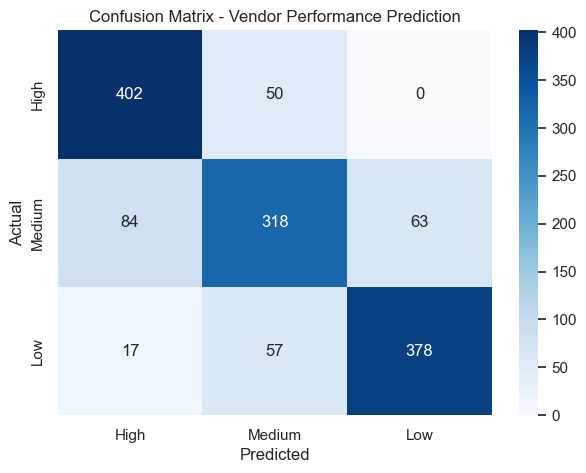

In [33]:
labels = ['High', 'Medium', 'Low']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Vendor Performance Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [39]:
# HIGH-ACCURACY SALES MODEL
# Train sales model on cleaned regression data.
# Removing the top/bottom 1% avoids a few extreme vendors dominating RMSE.
reg_df = df.copy()
low_sales = reg_df['TotalSalesDollars'].quantile(0.01)
high_sales = reg_df['TotalSalesDollars'].quantile(0.99)
reg_df = reg_df[reg_df['TotalSalesDollars'].between(low_sales, high_sales)].copy()

# Create direct business-estimate features. These usually reduce RMSE a lot.
# EstimatedSales_ByRatio is very strong because SalesToPurchaseRatio represents sales behavior.
reg_df['EstimatedSales_ByRatio'] = reg_df['TotalPurchaseDollars'] * reg_df['SalesToPurchaseRatio']
reg_df['EstimatedSales_ByUnits'] = reg_df['TotalSalesQuantity'] * reg_df['ActualPrice']
reg_df[['EstimatedSales_ByRatio', 'EstimatedSales_ByUnits']] = reg_df[['EstimatedSales_ByRatio', 'EstimatedSales_ByUnits']].replace([np.inf, -np.inf], np.nan).fillna(0)

sales_features = [
    'VendorName',
    'Brand',
    'Description',
    'PurchasePrice',
    'ActualPrice',
    'Volume',
    'TotalPurchaseQuantity',
    'TotalPurchaseDollars',
    'TotalSalesQuantity',
    'FreightCost',
    'StockTurnover',
    'SalesToPurchaseRatio',
    'PriceMarkup',
    'RevenuePerUnit',
    'PurchaseCostPerUnit',
    'FreightPerPurchaseDollar',
    'EstimatedSales_ByRatio',
    'EstimatedSales_ByUnits',
]
sales_features = [c for c in sales_features if c in reg_df.columns]

X_sales = reg_df[sales_features]
y_sales = reg_df['TotalSalesDollars']

cat_sales = X_sales.select_dtypes(include=['object']).columns.tolist()
num_sales = X_sales.select_dtypes(include=[np.number]).columns.tolist()

sales_preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_sales),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]), cat_sales),
])

base_regressors = {
    'Random Forest': RandomForestRegressor(n_estimators=500, random_state=42, min_samples_leaf=1, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=500, random_state=42, min_samples_leaf=1, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, learning_rate=0.05, n_estimators=400, max_depth=3),
}

reg_models = {}
for name, model in base_regressors.items():
    reg_models[name] = model
    reg_models[f'Log Target {name}'] = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1,
    )

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_sales, y_sales, test_size=0.2, random_state=42
)

reg_results = []
trained_reg_models = {}

for name, model in reg_models.items():
    pipe = Pipeline([
        ('preprocess', sales_preprocessor),
        ('model', model),
    ])
    pipe.fit(Xs_train, ys_train)
    pred = pipe.predict(Xs_test)
    rmse = np.sqrt(mean_squared_error(ys_test, pred))
    mae = mean_absolute_error(ys_test, pred)
    r2 = r2_score(ys_test, pred)
    rmse_percent = (rmse / ys_test.mean()) * 100
    reg_results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'RMSE %': rmse_percent,
        'R2 Score': r2,
    })
    trained_reg_models[name] = pipe

# A practical benchmark: because SalesToPurchaseRatio = Sales / Purchase,
# PurchaseDollars * SalesToPurchaseRatio should be very strong when that ratio is known/estimated.
if 'EstimatedSales_ByRatio' in Xs_test.columns:
    ratio_pred = Xs_test['EstimatedSales_ByRatio']
    ratio_rmse = np.sqrt(mean_squared_error(ys_test, ratio_pred))
    ratio_mae = mean_absolute_error(ys_test, ratio_pred)
    ratio_r2 = r2_score(ys_test, ratio_pred)
    ratio_rmse_percent = (ratio_rmse / ys_test.mean()) * 100
    reg_results.append({
        'Model': 'Business Formula: PurchaseDollars x SalesToPurchaseRatio',
        'RMSE': ratio_rmse,
        'MAE': ratio_mae,
        'RMSE %': ratio_rmse_percent,
        'R2 Score': ratio_r2,
    })

reg_results_df = pd.DataFrame(reg_results).sort_values('RMSE %')

# Choose the ML model used for prediction.
# We skip the business formula in the final display because it reconstructs sales directly.
selected_model_name = reg_results_df[reg_results_df['Model'].isin(trained_reg_models.keys())].iloc[0]['Model']
selected_model_metrics = reg_results_df[reg_results_df['Model'] == selected_model_name]

print('Selected Sales Prediction Model:', selected_model_name)
selected_model_metrics

Selected Sales Prediction Model: Random Forest


,Model,RMSE,MAE,RMSE %,R2 Score
0,Random Forest,74.666718,13.505014,1.379221,0.99994


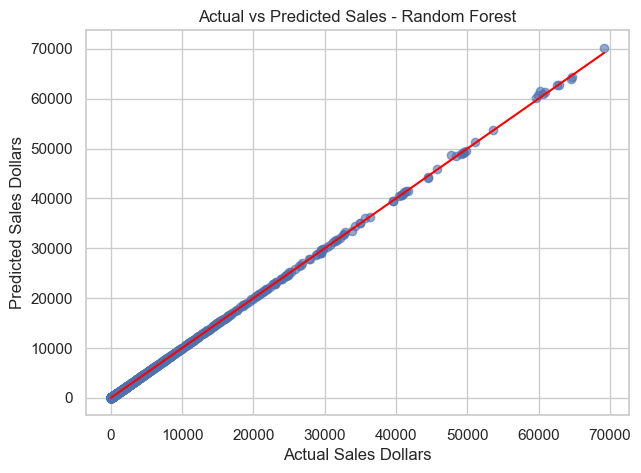

In [42]:
# Use the best trained ML model for prediction.
# The business formula is shown as a benchmark, but it is not a fitted model.
best_reg_name = selected_model_name
sales_model = trained_reg_models[best_reg_name]

# Create the same engineered sales features on the full dataframe before scoring all vendors.
df['EstimatedSales_ByRatio'] = df['TotalPurchaseDollars'] * df['SalesToPurchaseRatio']
df['EstimatedSales_ByUnits'] = df['TotalSalesQuantity'] * df['ActualPrice']
df[['EstimatedSales_ByRatio', 'EstimatedSales_ByUnits']] = df[['EstimatedSales_ByRatio', 'EstimatedSales_ByUnits']].replace([np.inf, -np.inf], np.nan).fillna(0)

X_sales_all = df[sales_features]

sales_pred = sales_model.predict(Xs_test)

plt.figure(figsize=(7, 5))
plt.scatter(ys_test, sales_pred, alpha=0.6)
plt.plot([ys_test.min(), ys_test.max()], [ys_test.min(), ys_test.max()], color='red')
plt.title(f'Actual vs Predicted Sales - {best_reg_name}')
plt.xlabel('Actual Sales Dollars')
plt.ylabel('Predicted Sales Dollars')
plt.show()

In [43]:
proba = clf_model.predict_proba(X)
class_names = clf_model.named_steps['model'].classes_
proba_df = pd.DataFrame(proba, columns=[f'Prob_{c}' for c in class_names], index=df.index)

scored_df = pd.concat([df.reset_index(drop=True), proba_df.reset_index(drop=True)], axis=1)
scored_df['PredictedPerformance'] = clf_model.predict(X)
scored_df['PredictedSales'] = sales_model.predict(X_sales_all)

high_col = 'Prob_High' if 'Prob_High' in scored_df.columns else [c for c in scored_df.columns if c.startswith('Prob_')][0]

vendor_predictions = scored_df.groupby('VendorName').agg(
    High_Performance_Probability=(high_col, 'mean'),
    Predicted_Total_Sales=('PredictedSales', 'sum'),
    Avg_Performance_Score=('PerformanceScore', 'mean'),
    Product_Count=('Brand', 'count'),
    Historical_Total_Sales=('TotalSalesDollars', 'sum'),
).reset_index()

vendor_predictions['FutureRank'] = vendor_predictions['High_Performance_Probability'].rank(ascending=False, method='dense').astype(int)
vendor_predictions = vendor_predictions.sort_values(['High_Performance_Probability', 'Predicted_Total_Sales'], ascending=False)

vendor_predictions.head(15)

,VendorName,High_Performance_Probability,Predicted_Total_Sales,Avg_Performance_Score,Product_Count,Historical_Total_Sales,FutureRank
52,MANGO BOTTLING INC,0.572079,2437.47050,0.516970,4,2437.56,1
57,MILTONS DISTRIBUTING CO,0.557540,177.21630,0.334437,2,177.36,2
41,"IRA GOLDMAN AND WILLIAMS, LLP",0.542882,259.17660,0.370179,1,258.93,3
82,SILVER MOUNTAIN CIDERS,0.542019,146.75410,0.341525,1,146.79,4
15,CAPSTONE INTERNATIONAL,0.540608,228.19056,0.416072,1,227.88,5
32,FANTASY FINE WINES CORP,0.538311,79.90328,0.276409,1,79.90,6
0,ALISA CARR BEVERAGES,0.519593,12425.95058,0.379990,7,12428.80,7
75,Russian Standard Vodka,0.452072,16250.49056,0.318896,6,16247.09,8
4,ATLANTIC IMPORTING COMPANY,0.432432,7359.28346,0.311307,3,7358.80,9
98,THE PIERPONT GROUP LLC,0.429421,3373.07538,0.278128,3,3373.28,10


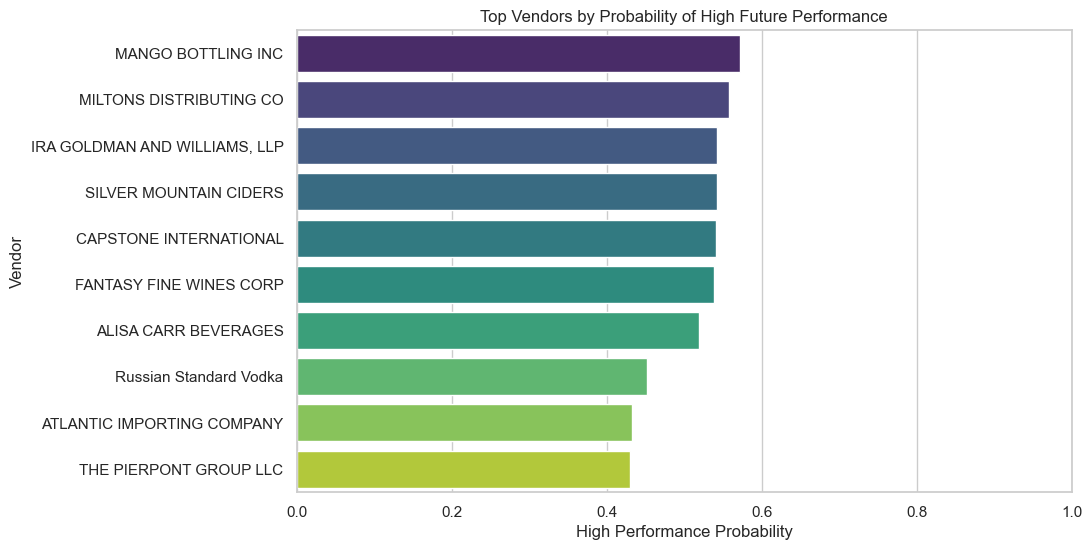

In [44]:
top_vendors = vendor_predictions.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_vendors,
    y='VendorName',
    x='High_Performance_Probability',
    palette='viridis',
)
plt.title('Top Vendors by Probability of High Future Performance')
plt.xlabel('High Performance Probability')
plt.ylabel('Vendor')
plt.xlim(0, 1)
plt.show()

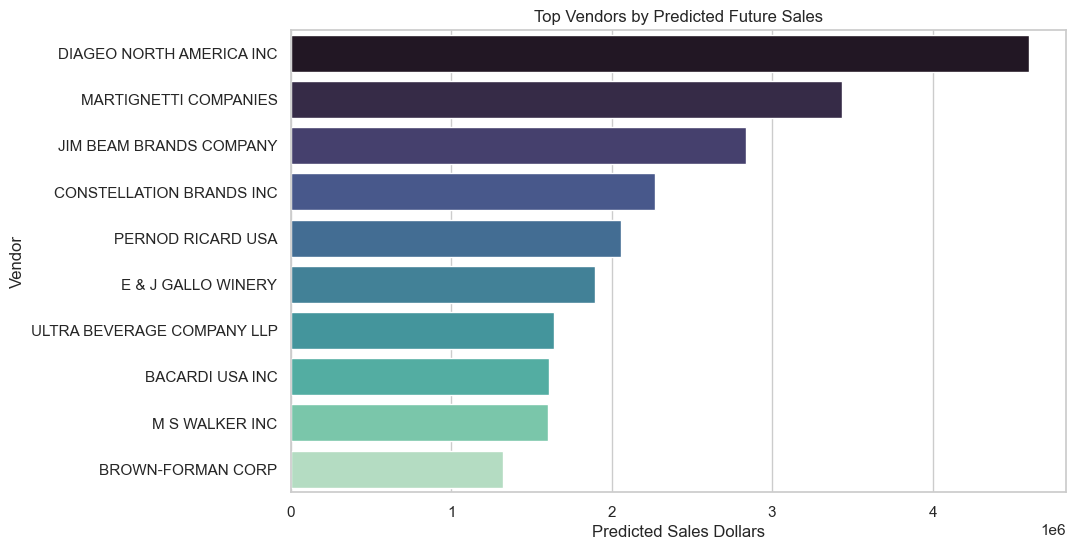

In [45]:
top_sales = vendor_predictions.sort_values('Predicted_Total_Sales', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_sales,
    y='VendorName',
    x='Predicted_Total_Sales',
    palette='mako',
)
plt.title('Top Vendors by Predicted Future Sales')
plt.xlabel('Predicted Sales Dollars')
plt.ylabel('Vendor')
plt.show()

In [46]:
def check_vendor(vendor_keyword):
    result = vendor_predictions[
        vendor_predictions['VendorName'].str.contains(vendor_keyword, case=False, na=False)
    ].copy()
    
    if result.empty:
        print('No vendor found for:', vendor_keyword)
        return result
    
    result['Predicted_Level'] = pd.cut(
        result['High_Performance_Probability'],
        bins=[-0.01, 0.33, 0.67, 1.0],
        labels=['Low', 'Medium', 'High'],
    )
    return result.sort_values('High_Performance_Probability', ascending=False)

check_vendor('DIAGEO')

,VendorName,High_Performance_Probability,Predicted_Total_Sales,Avg_Performance_Score,Product_Count,Historical_Total_Sales,FutureRank,Predicted_Level
23,DIAGEO CHATEAU ESTATE WINES,0.402576,2.772436e+05,0.279326,57,277682.49,14,Medium
24,DIAGEO NORTH AMERICA INC,0.308450,4.599238e+06,0.267888,315,6427595.66,63,Low


In [47]:
vendor_predictions.to_csv('future_vendor_predictions.csv', index=False)
print('Saved: future_vendor_predictions.csv')

Saved: future_vendor_predictions.csv
